© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [1]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib

seed_everything(0, verbose=False)

device = "cuda" 
img_idx = 30 

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [2]:
from datasets.cityscapes_semantic import CityscapesSemantic

data_path = "./cityscapes"

data = CityscapesSemantic(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
).setup()

## Load model

In [3]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

def load_model(config) :

    if "img_size" in config.get("data", {}) :
        img_size = config["data"]["img_size"]
    else :
        img_size = data.img_size

    if "num_classes" in config.get("data", {}) :
        num_classes = config["data"]["num_classes"]
    else :
        num_classes = data.num_classes

    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size = img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
    
    if "stuff_classes" in config.get("data", {}).get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = (
        lit_cls(
            img_size=img_size,
            num_classes=num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    return model

## Load the pretrained model from folder
Loads the two pre-trained model trained on Cityscapes and COCO

In [4]:
# Loads the cityscapes trained model

with open("./configs/eomt_semantic_trained_on_cityscapes.yaml", "r") as f:
    config = yaml.safe_load(f)

cityscapes_trained_model = load_model(config)
cityscapes_trained_state_dict = torch.load("./checkpoints/pretrained/eomt_cityscapes.bin",
                                            map_location = device,
                                            weights_only = True)
cityscapes_trained_model.load_state_dict(cityscapes_trained_state_dict)

<All keys matched successfully>

In [5]:
# Loads the coco trained model

with open("./configs/eomt_semantic_trained_on_coco.yaml", "r") as f:
    config = yaml.safe_load(f)

coco_trained_model = load_model(config)

coco_trained_state_dict = torch.load("./checkpoints/pretrained/eomt_coco.bin",
                                            map_location = device,
                                            weights_only = True)

coco_trained_model.load_state_dict(coco_trained_state_dict)

<All keys matched successfully>

## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

Cityscapes-trained model semantic prediction:


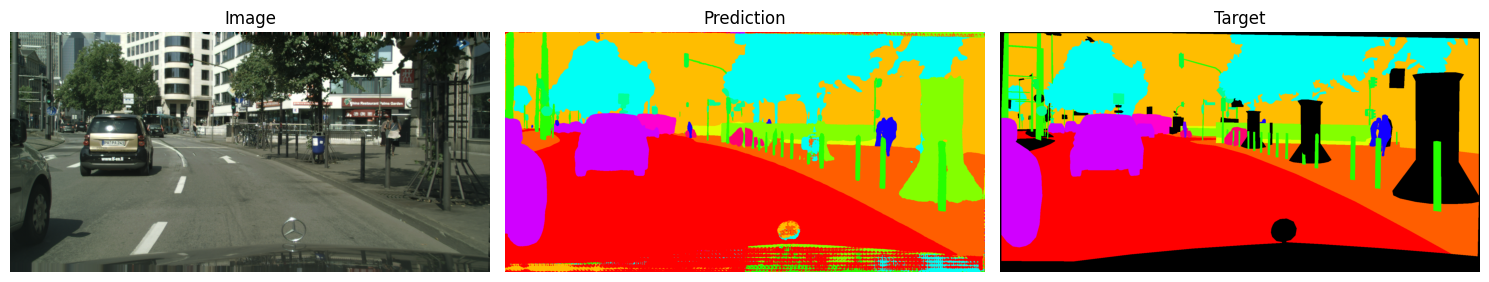

In [6]:
IGNORE_INDEX = 255


def infer_semantic(img, target, model):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"): 
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array



def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]

print("Cityscapes-trained model semantic prediction:")
pred_array, target_array = infer_semantic(img, target, cityscapes_trained_model)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

COCO-trained model panoptic prediction


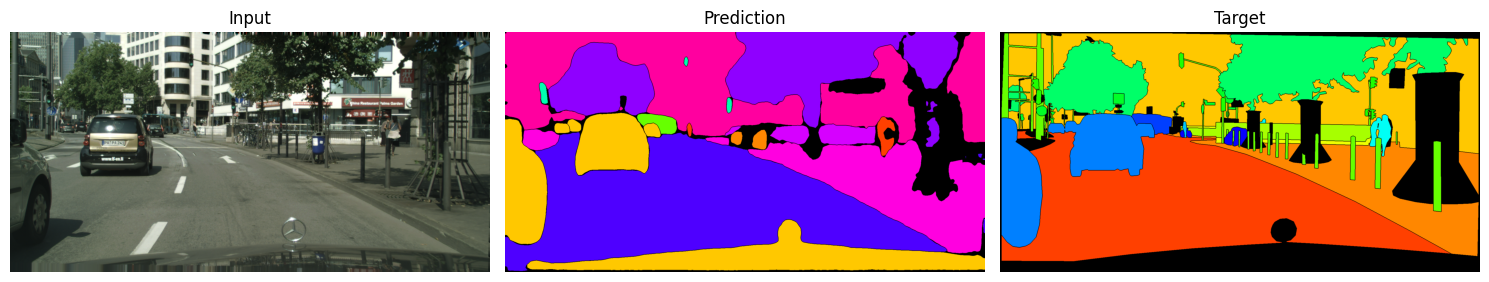

In [7]:
def infer_panoptic(img, target, model):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, model):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]

print("COCO-trained model panoptic prediction")
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target, coco_trained_model)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, coco_trained_model)

## Semantic evaluation

Evaluates the models trained on Cityscapes and COCO on the semantic segmentation task

In [8]:
# MAPPING COCO → CITYSCAPES
#
# One of the model was trained on COCO panoptic (133 classes)
# Cityscapes uses 19 semantic classes for training
# This dictionary maps each ID of a COCO class to the ID of the correspondent Cityscapes class
# COCO class with no corresponding Cityscapes class are mapped to the IGNORE_INDEX (255)


COCO_TO_CITYSCAPES = {
    0: 11,   # person -> person
    1: 18,   # bicycle -> bicycle
    2: 13,   # car -> car
    3: 17,   # motorcycle -> motorcycle
    4: 255,  # airplane -> void
    5: 15,   # bus -> bus
    6: 16,   # train -> train
    7: 14,   # truck -> truck
    8: 255,  # boat -> void
    9: 6,    # traffic light -> traffic light
    10: 255, # fire hydrant -> void
    11: 7,   # stop sign -> traffic sign
    12: 255, # parking meter -> void
    13: 255, # bench -> void
    14: 255, # bird -> void
    15: 255, # cat -> void
    16: 255, # dog -> void
    17: 255, # horse -> void
    18: 255, # sheep -> void
    19: 255, # cow -> void
    20: 255, # elephant -> void
    21: 255, # bear -> void
    22: 255, # zebra -> void
    23: 255, # giraffe -> void
    24: 255, # backpack -> void
    25: 255, # umbrella -> void
    26: 255, # handbag -> void
    27: 255, # tie -> void
    28: 255, # suitcase -> void
    29: 255, # frisbee -> void
    30: 255, # skis -> void
    31: 255, # snowboard -> void
    32: 255, # sports ball -> void
    33: 255, # kite -> void
    34: 255, # baseball bat -> void
    35: 255, # baseball glove -> void
    36: 255, # skateboard -> void
    37: 255, # surfboard -> void
    38: 255, # tennis racket -> void
    39: 255, # bottle -> void
    40: 255, # wine glass -> void
    41: 255, # cup -> void
    42: 255, # fork -> void
    43: 255, # knife -> void
    44: 255, # spoon -> void
    45: 255, # bowl -> void
    46: 255, # banana -> void
    47: 255, # apple -> void
    48: 255, # sandwich -> void
    49: 255, # orange -> void
    50: 255, # broccoli -> void
    51: 255, # carrot -> void
    52: 255, # hot dog -> void
    53: 255, # pizza -> void
    54: 255, # donut -> void
    55: 255, # cake -> void
    56: 255, # chair -> void
    57: 255, # couch -> void
    58: 255, # potted plant -> void
    59: 255, # bed -> void
    60: 255, # dining table -> void
    61: 255, # toilet -> void
    62: 255, # tv -> void
    63: 255, # laptop -> void
    64: 255, # mouse -> void
    65: 255, # remote -> void
    66: 255, # keyboard -> void
    67: 255, # cell phone -> void
    68: 255, # microwave -> void
    69: 255, # oven -> void
    70: 255, # toaster -> void
    71: 255, # sink -> void
    72: 255, # refrigerator -> void
    73: 255, # book -> void
    74: 255, # clock -> void
    75: 255, # vase -> void
    76: 255, # scissors -> void
    77: 255, # teddy bear -> void
    78: 255, # hair drier -> void
    79: 255, # toothbrush -> void
    80: 255, # banner -> void
    81: 255, # blanket -> void
    82: 255, # bridge -> void
    83: 255, # cardboard -> void
    84: 255, # counter -> void
    85: 255, # curtain -> void
    86: 255, # door-stuff -> void
    87: 255, # floor-wood -> void
    88: 8,   # flower -> vegetation
    89: 255, # fruit -> void
    90: 255, # gravel -> void
    91: 2,   # house -> building
    92: 255, # light -> void
    93: 255, # mirror-stuff -> void
    94: 255, # net -> void
    95: 255, # pillow -> void
    96: 255, # platform -> void
    97: 255, # playingfield -> void
    98: 255, # railroad -> void 
    99: 255, # river -> void
    100: 0,  # road -> road
    101: 2,  # roof -> building
    102: 255, # sand -> void
    103: 255, # sea -> void
    104: 255, # shelf -> void
    105: 255, # snow -> void
    106: 255, # stairs -> void
    107: 255, # tent -> void
    108: 255, # towel -> void
    109: 3,  # wall-brick -> wall
    110: 3,  # wall-stone -> wall
    111: 3,  # wall-tile -> wall
    112: 3,  # wall-wood -> wall
    113: 255, # water-other -> void
    114: 255, # window-blind -> void
    115: 255, # window-other -> void
    116: 8,  # tree-merged -> vegetation
    117: 4,  # fence-merged -> fence
    118: 255, # ceiling-merged -> void
    119: 10, # sky-other-merged -> sky
    120: 255, # cabinet-merged -> void
    121: 255, # table-merged -> void
    122: 255, # floor-other-merged -> void
    123: 1,  # pavement-merged -> sidewalk
    124: 255, # mountain-merged -> void
    125: 9,  # grass-merged -> terrain
    126: 9,  # dirt-merged -> terrain
    127: 255, # paper-merged -> void
    128: 255, # food-other-merged -> void
    129: 2,  # building-other-merged -> building
    130: 255, # rock-merged -> void
    131: 3,  # wall-other-merged -> wall
    132: 255  # rug-merged -> void
}

# Function that maps coco IDs on correspondent Cityscapes IDs

def map_coco_id_on_cityscapes_id(pred_coco: np.ndarray) -> np.ndarray:
    pred_city = np.full_like(pred_coco, fill_value=IGNORE_INDEX, dtype=np.int64)
    for coco_id, city_id in COCO_TO_CITYSCAPES.items():
        pred_city[pred_coco == coco_id] = city_id
    return pred_city


# Function that makes only a semantic prediction, without a target

def semantic_prediction(img, model):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"): 
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    return pred_array

# Function that evaluate the IoU of a model on a given dataloader

IGNORE_INDEX = 255
NUM_CITYSCAPES_CLASSES = 19

CITYSCAPES_CLASSES_NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

def evaluate_iou(iou_evaluator, model, dataloader) :
    for step, batch in enumerate(dataloader):
        img = batch[0][0] 
        target = batch[1][0] 
        pred_array = semantic_prediction(img, model)
    
        if isinstance(target, torch.Tensor) and target.dim() == 3:
            target_squeezed = target.squeeze(0)  
        else:
            target_squeezed = target

        target_array = model.to_per_pixel_targets_semantic(
            [target_squeezed], IGNORE_INDEX
        )[0].numpy()

        target_city = target_array.copy()
        target_city[target_city == IGNORE_INDEX] = NUM_CITYSCAPES_CLASSES  # 255 → 19

        if model.num_classes == 133 :
            pred_city = map_coco_id_on_cityscapes_id(pred_array)
        else :
            pred_city = pred_array

        pred_city[pred_city == IGNORE_INDEX] = NUM_CITYSCAPES_CLASSES      # 255 → 19
        pred_tensor   = torch.tensor(pred_city,   dtype=torch.long).unsqueeze(0).unsqueeze(0)
        target_tensor = torch.tensor(target_city, dtype=torch.long).unsqueeze(0).unsqueeze(0)

        iou_evaluator.addBatch(pred_tensor, target_tensor)

        if (step + 1) % 50 == 0 or (step + 1) == len(dataloader):
            print(f"  Images elaborated {step + 1}/{len(dataloader)}")

    return iou_evaluator


In [9]:
import sys
sys.path.insert(0,"..")
from eval.iouEval import iouEval, getColorEntry

# Semantic evaluation cityscapes model

iou_evaluator = iouEval(nClasses=NUM_CITYSCAPES_CLASSES + 1, ignoreIndex=NUM_CITYSCAPES_CLASSES)
iou_evaluator = evaluate_iou(iou_evaluator, cityscapes_trained_model, data.val_dataloader())

mean_iou, iou_per_classe = iou_evaluator.getIoU()

print("\n" + "=" * 50)
print("RESULTS EVALUATION IoU — Cityscapes trained model")
print("=" * 50)
print("IoU per class:")
print("-" * 40)

for i, name in enumerate(CITYSCAPES_CLASSES_NAMES):
    val = iou_per_classe[i].item()
    color = getColorEntry(val)
    print(f"  {color}{val*100:6.2f}%\033[0m  {name}")

print("=" * 50)
mean_val = mean_iou.item()
color_mean = getColorEntry(mean_val)
print(f"  mIoU: {color_mean}{mean_val*100:.2f}%\033[0m")
print("=" * 50)


# Semantic evaluation COCO model

iou_evaluator = iouEval(nClasses=NUM_CITYSCAPES_CLASSES + 1, ignoreIndex=NUM_CITYSCAPES_CLASSES)
iou_evaluator = evaluate_iou(iou_evaluator, coco_trained_model, data.val_dataloader())

mean_iou, iou_per_classe = iou_evaluator.getIoU()

print("\n" + "=" * 50)
print("RESULTS EVALUATION IoU — COCO trained model")
print("=" * 50)
print("IoU per class:")
print("-" * 40)

for i, name in enumerate(CITYSCAPES_CLASSES_NAMES):
    val = iou_per_classe[i].item()
    color = getColorEntry(val)
    print(f"  {color}{val*100:6.2f}%\033[0m  {name}")

print("=" * 50)
mean_val = mean_iou.item()
color_mean = getColorEntry(mean_val)
print(f"  mIoU: {color_mean}{mean_val*100:.2f}%\033[0m")
print("=" * 50)


  Images elaborated 50/500
  Images elaborated 100/500
  Images elaborated 150/500
  Images elaborated 200/500
  Images elaborated 250/500
  Images elaborated 300/500
  Images elaborated 350/500
  Images elaborated 400/500
  Images elaborated 450/500
  Images elaborated 500/500

RESULTS EVALUATION IoU — Cityscapes trained model
IoU per class:
----------------------------------------
   98.40%  road
   87.36%  sidewalk
   94.15%  building
   66.06%  wall
   65.49%  fence
   71.04%  pole
   75.00%  traffic light
   82.13%  traffic sign
   93.02%  vegetation
   66.60%  terrain
   95.54%  sky
   85.39%  person
   71.11%  rider
   95.54%  car
   81.79%  truck
   90.32%  bus
   77.35%  train
   74.35%  motorcycle
   81.27%  bicycle
  mIoU: 81.68%
  Images elaborated 50/500
  Images elaborated 100/500
  Images elaborated 150/500
  Images elaborated 200/500
  Images elaborated 250/500
  Images elaborated 300/500
  Images elaborated 350/500
  Images elaborated 400/500
  Images elaborated 450/50